In [2]:
# %%
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.expand_frame_repr", False)

from Scripts.weekly_view import build_weekly_view
from Scripts.config import COURSE_FIT_TEMPLATE, PLAYER_SKILL_TEMPLATE
from Scripts.schedule import build_season_schedule
from Scripts.features import compute_rolling_stats
from Scripts.preseason import (
    build_preseason_package,
    init_shortlist_template,
    load_shortlist,
    render_preseason_player_report,
)
from Scripts.data_io import (
    load_rounds,
    load_odds_and_results,
    load_course_fit,
    load_player_skills,
)
from Scripts.visuals import (
    subset_weekly_for_players,
    plot_recent_form_sg,
    plot_sg_component_profile,
    plot_ytd_profile,
    plot_ev_current_vs_future_max,
    plot_course_vs_players_radar_from_skills,
    print_event_history_for_player,
)

import warnings

warnings.filterwarnings("ignore")

pd.options.display.float_format = "{:,.2f}".format

# core config
SEASON_YEAR = 2024
TOP_N_PRESEASON = 30

# optional: where to log your manual picks (you can change this)
PICKS_LOG_PATH = Path(
    f"/Users/joshmacbook/python_projects/OAD/Data/in Use/OAD_{SEASON_YEAR}_manual_picks.csv"
)

PROJECT_ROOT = Path("/")
PICKS_PATH = PROJECT_ROOT / "Data" / "in Use" / f"OAD_{SEASON_YEAR}_manual_picks.csv"

COURSE_IMP_PATH = PROJECT_ROOT / "Data" / "in Use" / f"course_fit_{SEASON_YEAR}_dg_style_5attr.csv"
course_imp_df = pd.read_csv(COURSE_IMP_PATH)

def get_used_dg_ids_from_picks(picks_path: Path) -> set[int]:
    if not picks_path.exists():
        return set()

    df = pd.read_csv(picks_path)
    if "dg_id" not in df.columns:
        return set()

    return set(
        pd.to_numeric(df["dg_id"], errors="coerce")
        .dropna()
        .astype(int)
        .tolist()
    )

def apply_used_filter_to_weekly(weekly: dict, picks_path: Path) -> tuple[dict, set[int]]:
    used = get_used_dg_ids_from_picks(picks_path)
    weekly["used_dg_ids"] = used

    if not used:
        return weekly, used

    table_keys = [
        "table_performance",
        "table_performance_top50",
        "table_event_history",
        "table_event_history_top50",
        "table_ytd",
        "table_ytd_top50",
        "pattern_candidates",
    ]

    for key in table_keys:
        if key in weekly and isinstance(weekly[key], pd.DataFrame):
            df = weekly[key]
            if "dg_id" in df.columns:
                mask = ~df["dg_id"].astype(int).isin(used)
                weekly[key] = df[mask].copy()

    return weekly, used

In [3]:
# %%
rounds_df = load_rounds()
odds_df = load_odds_and_results()
course_fit_df = load_course_fit(SEASON_YEAR)
player_skills_df = load_player_skills(SEASON_YEAR)
schedule_df = build_season_schedule(SEASON_YEAR)

# rounds_df.head(), odds_df.head(), schedule_df.head()

In [2]:
from Scripts.preseason import (
    build_preseason_package,
    compute_preseason_baseline_windows_for_longlist,
    render_preseason_player_report,
)
from Scripts.data_io import load_rounds
from Scripts.schedule import build_season_schedule

SEASON_YEAR = 2024

# 1) package
pre_pkg = build_preseason_package(SEASON_YEAR, top_n=30)
longlist    = pre_pkg["longlist"]
big_hist_df = pre_pkg["major_sig_history"]

print("Preseason long list:")
display(longlist)

# 2) baselines as of first OAD event
rounds_df   = load_rounds()
sched       = build_season_schedule(SEASON_YEAR)
baseline_df = compute_preseason_baseline_windows_for_longlist(
    SEASON_YEAR,
    longlist,
    windows=(40, 24, 12),
)

# 3) example report
for dg in longlist["dg_id"].dropna().astype(int).tolist():
    print("=" * 80)
    print(
        render_preseason_player_report(
            season=SEASON_YEAR,
            dg_id=dg,
            longlist=longlist,
            baseline_df=baseline_df,
            big_hist_df=big_hist_df,
        )
    )
    print("\n")

Preseason long list:


,dg_id,hist_rounds,dec_wgh_sg,is_liv,target_season
0,10091,159,2.491725,False,2024
1,18417,162,2.405901,False,2024
2,19195,166,2.158878,False,2024
3,19895,153,1.929912,False,2024
4,15466,144,1.908783,False,2024
5,18841,181,1.839995,False,2024
6,14796,175,1.591100,False,2024
7,12294,180,1.537522,False,2024
8,15856,132,1.525348,True,2024
9,18079,132,1.471231,True,2024


Player dg_id 10091
Star power (dec_wgh_sg): 2.492

Baseline strokes gained (L40/L24/L12, pre season):
  L40: OTT +0.911, APP +0.868, ARG +0.207, PUTT +0.345, TOTAL +2.235 (n=40)  (rank 1/30 in shortlist)
  L24: OTT +0.682, APP +0.128, ARG +0.144, PUTT +0.728, TOTAL +1.930 (n=24)  (rank 5/30 in shortlist)
  L12: OTT +nan, APP +nan, ARG +nan, PUTT +nan, TOTAL +1.776 (n=12)  (rank 10/30 in shortlist)

Big-event history since 2017 (MAJOR + SIGNATURE, no playoffs):
  Masters Tournament (event_id 14)
    Starts: 7, Cuts made: 5, Top10: 4, Top25: 5
    Best finish: 2, Worst: 21, Avg: 8.0, Avg SG event: +6.04
  PGA Championship (event_id 33)
    Starts: 7, Cuts made: 7, Top10: 3, Top25: 4
    Best finish: 7, Worst: 50, Avg: 25.3, Avg SG event: +6.99
  The Open Championship (event_id 100)
    Starts: 6, Cuts made: 5, Top10: 4, Top25: 4
    Best finish: 2, Worst: 46, Avg: 12.2, Avg SG event: +8.47
  U.S. Open (event_id 26)
    Starts: 7, Cuts made: 5, Top10: 5, Top25: 5
    Best finish: 2, Worst

In [4]:
from Scripts.preseason import init_shortlist_template, get_shortlist_path
import os

SEASON_YEAR = 2024

path = get_shortlist_path(SEASON_YEAR)
if os.path.exists(path):
    os.remove(path)

# Now regenerate fresh
init_shortlist_template(SEASON_YEAR, top_n=30)

PosixPath('/Users/joshmacbook/python_projects/OAD/Data/in Use/preseason_shortlist_2024.csv')

In [5]:
# Helper: condensed decision table for a weekly view
def build_condensed_table(weekly: dict) -> pd.DataFrame:
    summary = weekly["summary"].copy()

    # make sure dg_id is numeric
    if "dg_id" in summary.columns:
        summary["dg_id"] = pd.to_numeric(summary["dg_id"], errors="coerce").astype("Int64")

    # drop already-used players if present
    used_ids = weekly.get("used_dg_ids", set())
    if used_ids:
        used_ids = {int(x) for x in used_ids}
        summary = summary[~summary["dg_id"].astype(int).isin(used_ids)]

    cols = [
        "dg_id",
        "is_shortlist",
        "oad_score",
        "decimal_odds",
        "ev_current_adj",
        "ev_future_max",
        "ev_current_to_future_max_ratio",

        "sg_total_L40",
        "sg_total_L24",
        "sg_total_L12",

        "starts_event",
        "made_cut_pct_event",
        "top25_event",
        "top10_event",
        "top5_event",
        "wins_event",
        "prev_finish_num_event",

        "ytd_starts",
        "ytd_made_cut_pct",
        "ytd_top25",
        "ytd_top10",
        "ytd_top5",
        "ytd_wins",
        "ytd_avg_sg_total",
    ]
    cols = [c for c in cols if c in summary.columns]

    out = summary[cols].copy()

    # robust sort: prefer oad_score, then ev_current_adj, then ev_current, else no sort
    sort_col = None
    for candidate in ["oad_score", "ev_current_adj", "ev_current"]:
        if candidate in out.columns:
            sort_col = candidate
            break

    if sort_col is not None:
        out = out.sort_values(sort_col, ascending=False)

    out = out.reset_index(drop=True)
    return out


# Helper: apply a dg_id filter to the three “top50” tables
def filter_top_tables_by_ids(weekly: dict, dg_ids) -> dict:
    ids = set(int(x) for x in dg_ids)
    out = weekly.copy()

    for key in ["table_performance_top50",
                "table_event_history_top50",
                "table_ytd_top50"]:
        df = out.get(key)
        if isinstance(df, pd.DataFrame) and "dg_id" in df.columns:
            out[key] = df[df["dg_id"].astype(int).isin(ids)].copy()

    return out


def load_picks_log(path: Path) -> pd.DataFrame:
    """
    Load the picks log if it exists, otherwise create a correctly-
    structured empty DataFrame.
    """
    if path.exists():
        return pd.read_csv(path)

    return pd.DataFrame(
        columns=[
            "year",
            "event_id",
            "event_name",
            "dg_id",
            "player_name",
            "decimal_odds",
            "ev_current",
            "ev_future_total",
            "ev_current_pct_of_future",
            "finish_num",
            "finish_text",
            "winnings",
        ]
    )


def log_pick(
    season_year: int,
    event_id: int,
    dg_id: int,
    weekly_raw: dict,      # IMPORTANT: use unfiltered weekly
    odds_df: pd.DataFrame,
    path: Path,
) -> pd.DataFrame:
    """
    Append a pick to the log file.
    weekly_raw must contain the *full* field (before removing used players).
    """
    log_df = load_picks_log(path)

    # event name
    event_name = weekly_raw["schedule_row"].iloc[0]["event_name"]

    # full performance row
    perf = weekly_raw["table_performance"]
    row = perf[perf["dg_id"] == dg_id]
    if row.empty:
        raise ValueError(f"dg_id {dg_id} not found in table_performance.")
    row = row.iloc[0]

    # player name
    player_name = None
    field_df = weekly_raw.get("field")
    if field_df is not None and "player_name" in field_df.columns:
        r = field_df[field_df["dg_id"] == dg_id]
        if not r.empty:
            player_name = r.iloc[0]["player_name"]

    # actual result from odds/results
    mask = (
        (odds_df["year"] == season_year) &
        (odds_df["event_id"] == event_id) &
        (odds_df["dg_id"] == dg_id)
    )
    res = odds_df[mask]
    if res.empty:
        finish_num = np.nan
        finish_text = None
        winnings = 0.0
    else:
        r0 = res.iloc[0]
        finish_num = r0.get("finish_num", np.nan)
        finish_text = r0.get("finish_text", None)
        winnings = r0.get("Winnings", 0.0)

    new_row = {
        "year": season_year,
        "event_id": event_id,
        "event_name": event_name,
        "dg_id": dg_id,
        "player_name": player_name,
        "decimal_odds": row.get("decimal_odds", np.nan),
        "ev_current": row.get("ev_current", np.nan),
        "ev_future_total": row.get("ev_future_total", np.nan),
        "ev_current_pct_of_future": row.get("ev_current_pct_of_future", np.nan),
        "finish_num": finish_num,
        "finish_text": finish_text,
        "winnings": winnings,
    }

    log_df = pd.concat([log_df, pd.DataFrame([new_row])], ignore_index=True)
    log_df.to_csv(path, index=False)
    return log_df


def inspect_picks_log(path: Path):
    """
    Display the existing picks log + cumulative winnings.
    """
    df = load_picks_log(path)
    if df.empty:
        print("Picks log is empty.")
        return df

    df["cum_winnings"] = df["winnings"].cumsum()

    print("Manual picks log:")
    display(df)

    print("\nCumulative winnings:")
    display(df[["event_name", "player_name", "winnings", "cum_winnings"]])

    return df


def preview_pick_result(picks_log: pd.DataFrame):
    """
    Show a minimal summary for the most recent logged pick:
      - player name
      - finish position
      - winnings
      - cumulative winnings
    """
    if picks_log.empty:
        print("No picks logged yet.")
        return

    picks_log = picks_log.copy()
    picks_log["cum_winnings"] = picks_log["winnings"].cumsum()

    row = picks_log.iloc[-1]  # last entry
    player = row.get("player_name", "")
    finish = row.get("finish_num", np.nan)
    winnings = row.get("winnings", 0.0)
    cum = row.get("cum_winnings", winnings)

    print("Latest Pick Summary:")
    print("---------------------")
    print(f"Player:        {player} (dg_id {int(row['dg_id'])})")
    print(f"Finish:        {finish}")
    print(f"Winnings:      ${winnings:,.0f}")
    print(f"Cumulative:    ${cum:,.0f}")

# WEEK TO WEEK RUN

In [9]:
# %%
from Scripts.features import compute_rolling_stats

pre_pkg = build_preseason_package(season=SEASON_YEAR, top_n=TOP_N_PRESEASON)

longlist = pre_pkg["longlist"]              # top N by decayed weighted SG
big_hist_df = pre_pkg["major_sig_history"]  # big-event history for all players

# --- build preseason baselines for the longlist only ---

# define a "preseason as-of date":
# either the first OAD event date, or if you prefer, the first PGA event date.
preseason_as_of = schedule_df["event_date"].min()

baseline_df = compute_rolling_stats(
    rounds_df=rounds_df,
    as_of_date=preseason_as_of,
    dg_ids=longlist["dg_id"].dropna().astype(int).tolist(),
    windows=(40, 24, 12),
)

# print("Preseason long list:")
# display(longlist)
#
# print("\nPreseason baselines (L40/L24/L12) for longlist players:")
# display(baseline_df.head())
#
# print("\nBig-event history (all years):")
# display(big_hist_df.head())

In [10]:
# %%
# One-time template creation (safe to re-run; it won't overwrite existing file)
shortlist_template_path = init_shortlist_template(season=SEASON_YEAR, top_n=TOP_N_PRESEASON)
print("Shortlist template at:", shortlist_template_path)

# After editing the CSV in your IDE, load it:
shortlist_df = load_shortlist(SEASON_YEAR)

# print("Current preseason shortlist (after manual edits):")
# display(shortlist_df.head())

Shortlist template at: /Users/joshmacbook/python_projects/OAD/Data/in Use/preseason_shortlist_2024.csv


In [71]:
# %%
INDEX = 28

EVENT_ID = int(schedule_df.iloc[INDEX]["event_id"])
weekly_raw = build_weekly_view(SEASON_YEAR, EVENT_ID)
weekly, used_ids = apply_used_filter_to_weekly(weekly_raw.copy(), PICKS_PATH)

print(f"Building weekly view for {SEASON_YEAR}, event_id = {EVENT_ID}")
weekly = build_weekly_view(SEASON_YEAR, EVENT_ID)

weekly, used_ids = apply_used_filter_to_weekly(weekly, PICKS_PATH)
print(f"Used players from manual picks: {len(used_ids)} dg_ids filtered out.")

print("Event context:")
display(weekly["schedule_row"])
#
# print("\nPatterns summary text:")
# print(weekly["patterns_summary_text"])

# print("\nPattern-matched candidates (winner/top-5 archetype, field-only):")
# display(weekly["pattern_candidates"])

# -----------------------------
# Condensed decision table (whole field, ranked by oad_score)
# -----------------------------
condensed = build_condensed_table(weekly)
print("\nCondensed decision table:")
display(condensed.head(5))

Building weekly view for 2024, event_id = 13
Used players from manual picks: 28 dg_ids filtered out.
Event context:


,year,start_date,event_name,purse,winner_share,event_id,course_name,course_num,rank,event_date,avg_skill,x_score,Event_Tier
28,2024,2024-08-12 00:00:00,Wyndham Championship,7900000,1422000,13,Sedgefield Country Club,752,28,2024-08-11 00:00:00,–0.18,0.91,REGULAR



Condensed decision table:


,dg_id,is_shortlist,oad_score,decimal_odds,ev_current_adj,ev_future_max,ev_current_to_future_max_ratio,sg_total_L40,sg_total_L24,sg_total_L12,starts_event,made_cut_pct_event,top25_event,top10_event,top5_event,wins_event,prev_finish_num_event,ytd_starts,ytd_made_cut_pct,ytd_top25,ytd_top10,ytd_top5,ytd_wins,ytd_avg_sg_total
0,13900,False,0.79,26.00,"304,824.73","281,690.14",1.08,0.62,1.09,1.40,5.00,0.80,2.00,1.00,0.00,0.00,51.00,15.00,0.93,8.00,5.00,2.00,0.00,0.90
1,18554,False,0.75,29.00,"273,291.13","198,019.80",1.38,1.55,1.75,0.98,2.00,0.50,0.00,0.00,0.00,0.00,NaN,18.00,0.83,8.00,5.00,3.00,0.00,1.04
2,27364,False,0.72,31.00,"255,659.45","180,180.18",1.41,1.61,2.16,1.06,2.00,0.50,1.00,0.00,0.00,0.00,22.00,19.00,0.74,8.00,3.00,2.00,1.00,1.11
3,14609,False,0.71,23.00,"344,584.47","434,782.61",0.79,0.49,0.49,0.25,6.00,0.67,3.00,3.00,3.00,0.00,33.00,20.00,0.95,10.00,1.00,0.00,0.00,0.81
4,16283,False,0.69,71.00,"111,625.96","116,959.06",0.95,0.51,0.99,1.65,6.00,0.50,1.00,0.00,0.00,0.00,NaN,20.00,0.70,7.00,3.00,1.00,0.00,0.30


In [72]:
PICK_DG_ID = 13900

picks_log = log_pick(
    SEASON_YEAR,
    EVENT_ID,
    PICK_DG_ID,
    weekly_raw,     # must be unfiltered
    odds_df,
    PICKS_LOG_PATH,
)

preview_pick_result(picks_log)

Latest Pick Summary:
---------------------
Player:        Lowry, Shane (dg_id 13900)
Finish:        -
Winnings:      $0
Cumulative:    $10,571,538


In [73]:
;# -----------------------------
# Choose which dg_ids you want detailed tables for
# - If you leave FOCUS_DG_IDS empty, we’ll default to top 25 by oad_score
# -----------------------------
FOCUS_DG_IDS = [13900]  # e.g. [19895, 18417]; leave [] to use top 25

if FOCUS_DG_IDS:
    focus_ids = FOCUS_DG_IDS
else:
    focus_ids = condensed.head(25)["dg_id"].astype(int).tolist()

weekly_f = filter_top_tables_by_ids(weekly, focus_ids)

print("\nFiltered performance table (focus players only):")
display(weekly_f["table_performance_top50"])

print("\nFiltered event history table (same dg_ids):")
display(weekly_f["table_event_history_top50"])

print("\nFiltered YTD table (same dg_ids):")
display(weekly_f["table_ytd_top50"])


Filtered performance table (focus players only):


,dg_id,decimal_odds,ev_current,ev_current_adj,ev_future_total,ev_future_max,ev_future_total_adj,ev_future_max_adj,ev_current_to_future_max_ratio,z_sg_recent,z_ytd,z_history,z_ev_current,oad_score,course_fit_score,is_shortlist,tagged_here,pattern_score_winner,pattern_score_top5,sg_total_L40,sg_app_L40,sg_putt_L40,round_score_L40,sg_total_L24,sg_app_L24,sg_putt_L24,round_score_L24,sg_total_L12,sg_app_L12,sg_putt_L12,round_score_L12
7,13900,26.00,"303,846.00","304,824.73","563,380.00","281,690.14","565,194.72","282,597.36",1.08,0.85,0.88,0.62,0.50,0.79,0.39,False,False,8,9,0.62,0.60,-0.15,70.38,1.09,0.75,0.08,70.00,1.40,1.10,0.07,69.08



Filtered event history table (same dg_ids):


,dg_id,starts_event,made_cuts_event,made_cut_pct_event,top25_event,top10_event,top5_event,wins_event,prev_finish_num_event,avg_score_event,avg_sg_total_event
7,13900,5.00,4.00,0.80,2.00,1.00,0.00,0.00,51.00,68.50,0.54



Filtered YTD table (same dg_ids):


,dg_id,ytd_starts,ytd_made_cuts,ytd_made_cut_pct,ytd_top25,ytd_top10,ytd_top5,ytd_wins,ytd_avg_score,ytd_avg_sg_total
7,13900,15.00,14.00,0.93,8.00,5.00,2.00,0.00,70.15,0.90


In [40]:
print_event_history_for_player(weekly, 14139)
print("---")
# print_event_history_for_player(weekly, 17511)
# print("---")
# print_event_history_for_player(weekly, 23602)
# print("---")
# print_event_history_for_player(weekly, 22085)

Event history for dg_id 14139 at WM Phoenix Open (event_id 3), years 2017–2024


,year,finish_num,fin_text,sg_event
0,2017,NaN,CUT,-0.95
1,2018,17.00,T17,8.05
2,2019,3.00,3,12.06
3,2020,3.00,T3,10.86
4,2021,13.00,T13,6.23
5,2022,8.00,T8,9.91
6,2023,4.00,4,11.89
7,2024,12.00,T12,7.26



Summary:
Starts: 8
Best finish: 3.0
Top-10s: 4
Top-25s: 7
Wins: 0
---


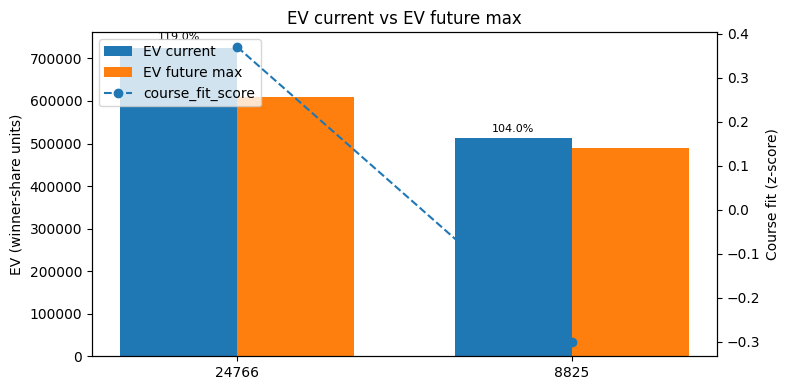

,dg_id,decimal_odds,ev_current,ev_future_max,ev_current_vs_future_max_pct,course_fit_score
0,24766,12.00,"725,000.00","609,756.10",1.19,0.37
1,8825,17.00,"511,765.00","490,196.08",1.04,-0.30


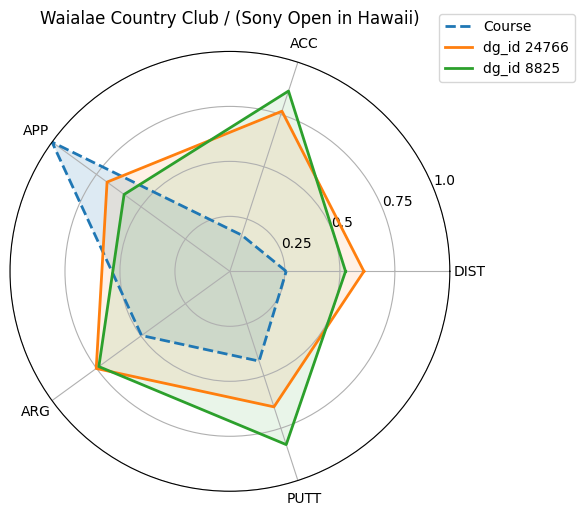

In [26]:
dg_focus = [24766, 8825]

slices = subset_weekly_for_players(weekly, dg_focus)
perf_slice = slices["performance"]
ytd_slice  = slices["ytd"]

# EV vs future max + course fit
comparison = plot_ev_current_vs_future_max(perf_slice)
display(comparison)

# Course vs players radar (5-attr)
plot_course_vs_players_radar_from_skills(
    weekly,
    course_fit_df,       # course_fit_2024_dg_style_5attr.csv as a DF
    player_skills_df,    # player_skill_5attr_hist_to_2024.csv as a DF
    dg_focus,
)

In [ ]:
from pathlib import Path
import pandas as pd
from Scripts.data_io import load_rounds

SEASON_YEAR = 2024
PROJECT_ROOT = Path("/")
PICKS_PATH = PROJECT_ROOT / "Data" / "in Use" / f"OAD_{SEASON_YEAR}_manual_picks.csv"

# 1) Load existing picks
picks = pd.read_csv(PICKS_PATH)

# 2) Build dg_id -> player_name map from rounds
rounds = load_rounds()
name_map = (
    rounds[["dg_id", "player_name"]]
    .dropna(subset=["dg_id", "player_name"])
    .drop_duplicates()
)

name_map["dg_id"] = pd.to_numeric(name_map["dg_id"], errors="coerce").astype("Int64")
picks["dg_id"] = pd.to_numeric(picks["dg_id"], errors="coerce").astype("Int64")

# 3) Merge names in
picks_with_names = picks.merge(name_map, on="dg_id", how="left")

display(picks_with_names.head(35))

# 4) Overwrite (or write to a new file if you want a dry run first)
picks_with_names.to_csv(PICKS_PATH, index=False)
print("Updated picks file with player_name:", PICKS_PATH)
